In [1]:
#Spam Detection Model using CNN
import tensorflow as tf
tf.__version__

2024-09-13 10:50:32.916976: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


'2.16.1'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
data = pd.read_csv('SMSSpamCollection', sep="\t", names = ['label','message'])

FileNotFoundError: [Errno 2] No such file or directory: 'SMSSpamCollection'

In [4]:
data.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [6]:
#Binarize labels
data['label']=data['label'].map({'ham':0, 'spam':1})
data.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
data

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will ü b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [8]:
#Seperate data as features and label
features = data.message.values
label = data.label.values

In [9]:
#Train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(features,
                                                 label,
                                                 test_size=0.2,
                                                 random_state = 1)

In [10]:
# For Tokenization
from tensorflow.keras.preprocessing.text import Tokenizer

#Decide the Vocabulary Word Frequency Size

vocabFreqWordSize = None

# If the word 'spiderman' exists a minimum of num_words times in the corpus,
# then it will be added in the vocab dictionary

#Convert the sentences into sequence of words

tokenizer = Tokenizer(num_words=vocabFreqWordSize)

#Fit the training data

tokenizer.fit_on_texts(X_train)




In [11]:
#Lets create the sequence objects

seq_train = tokenizer.texts_to_sequences(X_train)
seq_test = tokenizer.texts_to_sequences(X_test)

In [12]:
X_train[0]

"Hi , where are you? We're at  and they're not keen to go out i kind of am but feel i shouldn't so can we go out tomo, don't mind do you?"

In [13]:
len(seq_train[3])

34

In [14]:
len(seq_train)

4457

In [15]:
#Lets pad the sequence data
#This creates a matrix where the
# rows = Documents
# Cols = Time Steps (For our understanding its the vocab with padding)

from tensorflow.keras.preprocessing.sequence import pad_sequences

trainData = pad_sequences(seq_train)
T = trainData.shape[1]
T

189

In [16]:
trainData.shape

(4457, 189)

In [17]:
testData = pad_sequences(seq_test , maxlen=T)
testData.shape

(1115, 189)

In [18]:
#Build the Model
#Question: Can we use ANN?
#Answer: We can use ANN if the dataset is small. BUt preferred is CNN due to data size and avoiding memory overflow issue
# and without compromising the quality of the data.

In [19]:
#Get the Vocab Size of the Tokenizer
V = len(tokenizer.word_index)

In [20]:
#CNN for Text data -- Conv1D



from tensorflow.keras.layers import Dense,Input,Conv1D,Embedding,MaxPooling1D,GlobalMaxPooling1D
from tensorflow.keras.models import Model

# 1. Create/Convert Seq data into Word Embedding / Embedded Data

#Input layer -  It takes in sequence of Integers i.e. T  (time step size ////// vocab size)

i = Input(shape=(T,))

#Create WordEmbedding ---- This layer will take sequence of integers and return sequence of word vectors
# Ideally input size is No of Docs X Time Steps
# When creating word embedding the dimension of matrix will be (Total_Vocabulary_Size + 1,Embedding Dim)
# Reason for + 1 is indexing of embedding starts from 1 and not 0


#You can decide the Embedding Dimensionality -- Hyperparameter
#Prashant Recommend ----> 10 to 100
D = 20

x = Embedding(V + 1,D)(i)

#First Convolution Layer

x = Conv1D(32,3,activation='relu')(x)
x = MaxPooling1D(3)(x)

#Second Convolution Layer

x = Conv1D(64,3,activation='relu')(x)
x = MaxPooling1D(3)(x)

#Third Convolution Layer

x = Conv1D(128,3,activation='relu')(x)
#x = Flatten()(x)
x = GlobalMaxPooling1D()(x)

#Dense Layer -- Output Layer

x = Dense(1,activation='sigmoid')(x)


model = Model(i,x)


In [21]:
#Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [22]:
#Train
history = model.fit(trainData,y_train, epochs=5, validation_data=(testData,y_test))

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.8420 - loss: 0.4203 - val_accuracy: 0.9731 - val_loss: 0.0882
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9828 - loss: 0.0647 - val_accuracy: 0.9910 - val_loss: 0.0320
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9929 - loss: 0.0270 - val_accuracy: 0.9901 - val_loss: 0.0330
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9979 - loss: 0.0106 - val_accuracy: 0.9937 - val_loss: 0.0191
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9993 - loss: 0.0027 - val_accuracy: 0.9919 - val_loss: 0.0228


In [23]:
# ANN Model Approach Code Style

In [24]:
from tensorflow.keras.layers import Dense,Input,Conv1D,Embedding,MaxPooling1D,GlobalMaxPooling1D,GlobalAveragePooling1D,Dropout
from tensorflow.keras.models import Sequential
"""
##max_len=T #no of cols in the pad_seq of train data
embedding_dim=20

#hyperparameter
vocab_size=len(tokenizer.word_index) #trained tokenizer object word index
max_len=T
model = Sequential()
model.add(Embedding(vocab_size, embedding_dim, input_length=max_len))
model.add(Conv1D(128,3,activation='relu'))

model.add(MaxPooling1D(3))
model.add(GlobalAveragePooling1D())
model.add(Dense(24, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))
"""
#Compile


#Fit



"\n##max_len=T #no of cols in the pad_seq of train data\nembedding_dim=20\n\n#hyperparameter\nvocab_size=len(tokenizer.word_index) #trained tokenizer object word index\nmax_len=T\nmodel = Sequential()\nmodel.add(Embedding(vocab_size, embedding_dim, input_length=max_len))\nmodel.add(Conv1D(128,3,activation='relu'))\n\nmodel.add(MaxPooling1D(3))\nmodel.add(GlobalAveragePooling1D())\nmodel.add(Dense(24, activation='relu'))\nmodel.add(Dropout(0.2))\nmodel.add(Dense(1, activation='sigmoid'))\n"

In [25]:
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense,Input,Conv1D,Embedding,MaxPooling1D,GlobalMaxPooling1D,GlobalAveragePooling1D,Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten #
embedding_dim=20

#hyperparameter
vocab_size=len(tokenizer.word_index) #trained tokenizer object word index
max_len=T
print ("vocab_size", vocab_size)
print ("max_len",max_len )
model = Sequential()
model.add (Embedding(vocab_size, embedding_dim, input_length=max_len))
model.add(LSTM(units=128, return_sequences=True))
model.add(Flatten()) # Added Flatten layer
model.add(Dense(22, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))

vocab_size 7968
max_len 189


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [26]:
#Custom Callback for early stopping

class MyThresholdCallBack(tf.keras.callbacks.Callback):
    def __init__(self,cl):
        super(MyThresholdCallBack, self).__init__()
        self.cl = cl

    def on_epoch_end(self, epoch, logs=None):
        test_score = logs["val_accuracy"]
        train_score = logs["accuracy"]

        #if test_score > train_score and test_score > self.cl:
        #if test_score > self.cl:
        #    self.model.stop_training = True

In [27]:
myR2ScoreMonitor = MyThresholdCallBack(cl=0.95)

In [28]:
#Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [29]:
#Train

history = model.fit(trainData,y_train, epochs=20, validation_data=(testData,y_test),callbacks=[myR2ScoreMonitor])

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9025 - loss: 0.2930 - val_accuracy: 0.9848 - val_loss: 0.0460
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9895 - loss: 0.0450 - val_accuracy: 0.9830 - val_loss: 0.0442
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9942 - loss: 0.0209 - val_accuracy: 0.9946 - val_loss: 0.0190
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9989 - loss: 0.0082 - val_accuracy: 0.9946 - val_loss: 0.0210
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9991 - loss: 0.0068 - val_accuracy: 0.9794 - val_loss: 0.0813
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9984 - loss: 0.0097 - val_accuracy: 0.9812 - val_loss: 0.0689
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9971 - loss: 0.0144 - val_accuracy: 0.9928 - val_loss: 0.0226
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9985 - loss: 0.0083 - val_accu

In [42]:
#Create Deployment code of User Input in Jupyter Notebook --

history.history

{'accuracy': [0.934036374092102,
  0.9890060424804688,
  0.9950639605522156,
  0.9986538290977478,
  0.9979807138442993,
  0.9975319504737854,
  0.9977563619613647,
  0.9988781809806824,
  0.9997756481170654,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  0.9997756481170654,
  1.0,
  1.0,
  1.0],
 'loss': [0.1868268847465515,
  0.0436539389193058,
  0.018676722422242165,
  0.010766295716166496,
  0.010779967531561852,
  0.013450827449560165,
  0.03893876448273659,
  0.005602747667580843,
  0.0008017462096177042,
  0.0005357188638299704,
  0.00018695686594583094,
  0.00031997638870961964,
  0.00016103948291856796,
  5.89905321248807e-05,
  6.908144860062748e-05,
  0.0001089552097255364,
  0.000179481809027493,
  1.762185820552986e-05,
  1.6859125025803223e-05,
  2.1772913896711543e-05],
 'val_accuracy': [0.9847533702850342,
  0.9829596281051636,
  0.994618833065033,
  0.994618833065033,
  0.9793722033500671,
  0.9811659455299377,
  0.9928250908851624,
  0.994618833065033,
  0.993721

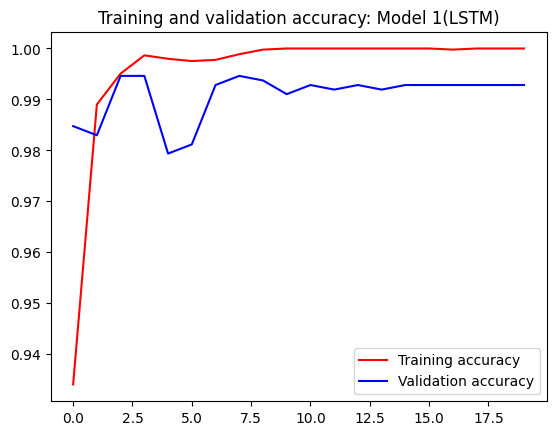

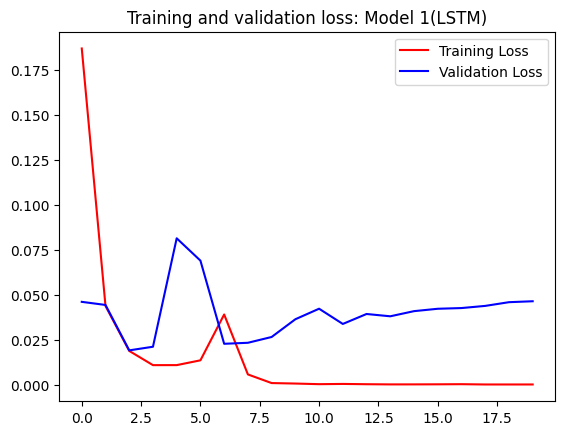

In [44]:
# plotting accuracy/loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy: Model 1(LSTM)')
plt.legend()
plt.figure()

plt.plot(epochs, loss, 'r', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and validation loss: Model 1(LSTM)')
plt.legend()

plt.show()


In [31]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 189, 20)             │         159,360 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 189, 128)            │          76,288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 24192)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 22)                  │         532,246 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 22)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              23 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,303,753 (8.79 MB)

 Trainable params: 767,917 (2.93 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,535,836 (5.86 MB)

In [32]:
pred = model.predict(testData)
pred[:200]

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


array([[1.29383722e-07],
       [7.70601645e-08],
       [3.39175244e-07],
       [5.12640008e-06],
       [1.21446675e-08],
       [6.12202067e-10],
       [9.82549227e-06],
       [2.43540139e-08],
       [1.90789578e-07],
       [6.83874868e-09],
       [1.69563663e-09],
       [4.43605273e-07],
       [9.31162560e-08],
       [6.92683884e-08],
       [8.44596337e-10],
       [8.27930702e-09],
       [1.00000000e+00],
       [6.67488109e-08],
       [1.00000000e+00],
       [3.02528434e-07],
       [4.13552970e-10],
       [1.85167381e-09],
       [2.17430767e-08],
       [9.10991744e-08],
       [7.64262111e-08],
       [1.02578986e-06],
       [3.12681898e-08],
       [1.85206375e-07],
       [4.51558430e-10],
       [5.91000626e-09],
       [2.17382603e-06],
       [1.26824898e-10],
       [1.11635510e-08],
       [1.77420767e-09],
       [2.04863591e-06],
       [2.40969253e-08],
       [1.06446167e-08],
       [6.80235246e-08],
       [9.46171497e-07],
       [5.75227439e-08],


In [33]:
y_test

array([0, 0, 0, ..., 0, 0, 0])

In [34]:
#userString="Go have fun."
userString ="Free entry in 2 a wkly comp to win FA Cup fina."

In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import nltk
from nltk.corpus import stopwords
import re
#Preprocess the text data
def preprocess_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'\W', ' ', text)  # Remove punctuation and special characters
    text = re.sub(r'\s+', ' ', text)  # Remove extra spaces
    text = re.sub(r'\d', '', text)  # Remove numbers
    stop_words = set(stopwords.words('english'))
    words = text.split()
    text = ' '.join([word for word in words if word not in stop_words])
    print ('text', text)
    return text

In [36]:
import pandas as pd
import nltk
nltk.download('stopwords')
data ={}
data['message'] = [userString]
data['label'] = 0
data = pd.DataFrame(data)
#data['message'].apply(preprocess_text)
data['message'] = data['message'].apply(preprocess_text)

text free entry wkly comp win fa cup fina


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [37]:
seq_test_example= tokenizer.texts_to_sequences(data['message'])
seq_test_example

[[49, 543, 880, 952, 178, 3779, 1291]]

In [38]:
test_example = pad_sequences(seq_test_example , maxlen=T)
test_example.shape

(1, 189)

In [39]:
result = model.predict(test_example)
result

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


array([[0.99854547]], dtype=float32)

In [40]:

#Compile

In [41]:
#from tensorflow.keras.layers import LSTM
#model = Sequential()
#model.add (Embedding(vocab_size, embedding_dim, input_length=max_len))
#model.add(LSTM(units=128, return_sequences=True))
#model.add(Dense(22, activation='relu'))
#model.add(Dropout(0.2))
#model.add(Dense(1, activation='sigmoid'))
